# 03 · Pool projection & scenarios: the handoff to the waterfall

**Purpose.** Project the whole STACR reference pool month by month to the Feb 2031 call (53 months) under several scenarios, and produce the table that Smarajit's `src/waterfall.py` consumes. His waterfall only needs this table, not how CPR or defaults were modeled.

**Process (`src/collateral_projection.py`).**
1. **Scheduled principal**: level-pay amortization. Payment = B·r / (1 − (1+r)⁻ⁿ), and principal = payment − B·r. Checked by hand: $300k, 6.75%, 342 months gives month-1 principal of $290.46.
2. **`project_collateral`, one path.** Each month, in this order so no dollar leaves twice:
   1. *Defaults*: MDR × performing balance enter a 19-month **liquidation pipeline** (fitted median). They stay in the reference pool, counted in `distressed_balance`, which feeds the STACR Delinquency Test. 57% of new default spells never liquidate (cure, modification or payoff in the data); they stay performing at a slightly lower rate.
   2. *Scheduled principal* on the remaining performing balance.
   3. *Prepayments*: SMM × (balance after scheduled principal).
   4. *Credit events*: loans whose 19-month lag ends leave the pool, and **loss** = balance × severity at that month's HPI. Loans already 60+ days delinquent or in bankruptcy/foreclosure on the tape start in the pipeline and liquidate in month 9.

   Balance identity: ending = beginning − scheduled − prepayments − credit events (checked every month).
3. **`run_scenarios`** on `get_scenarios()`: Coco's paths from `data/scenarios/scenarios.csv` when that file exists, otherwise **interim** good / base / moderate / severe paths built around today's PMMS of 7.28% (see `data/scenarios/README.md` for the file format).
4. **Figure 3** and a summary of cumulative losses against the tranche attachment points.
5. **Save** each scenario's table to `outputs/pool_cf_<scenario>.parquet` for the waterfall.

Output columns: `month, beginning_balance, scheduled_principal, prepayments, defaults (credit events), losses, recoveries, ending_balance, modification_losses, distressed_balance`, all in $.

In [1]:
import sys, warnings
from pathlib import Path

# Find the repo root (the folder that contains src/) so imports work from anywhere
ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)  # pandas 2.2 + Python 3.14 noise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", "{:,.4f}".format)
print("repo root:", ROOT)

repo root: /Users/reza/Desktop/mfe-term_3/asset backed scurity market /stacr-crt-pricing


**Q&A · Setup**

**Q: Why does the first cell search upward for a folder containing `src/`?**
A: The model code lives in `src/` at the repo root. Jupyter may start in the repo root or in `notebooks/`, so the cell walks up the folder tree until it finds `src/` and adds that folder to `sys.path`. Then `from src import ...` works wherever the notebook is opened.

**Q: Why are FutureWarnings turned off? Doesn't that hide problems?**
A: pandas 2.2 running on Python 3.14 prints spurious "chained assignment" warnings from `clean.py`, which drown out the real output. Only *warnings* are hidden. Real errors still stop the cell, so nothing that would make a result wrong is suppressed.

In [2]:
def try_run(fn, *args, **kwargs):
    """Call a model function; if it's still a stub, say so instead of crashing."""
    try:
        return fn(*args, **kwargs)
    except NotImplementedError:
        print(f"-> {fn.__module__}.{fn.__name__} is not implemented yet")
        return None

**Q&A · `try_run`**

**Q: What does `try_run` do, and is it still needed?**
A: It calls a model function and, if the function raises `NotImplementedError`, prints "not implemented yet" instead of crashing. It dates from the scaffold stage, when the functions were empty stubs. Every function is implemented now, so `try_run` just returns the result. It's harmless and keeps the notebook runnable if a function is ever replaced by a stub again.

In [3]:
from src import collateral_projection as cp
pool = pd.read_parquet(ROOT / "data" / "processed" / "stacr_dna1.parquet")
print(f"{len(pool):,} loans, ${pool['Current Balance'].sum()/1e9:.2f}bn")
print('output columns:', cp.COLUMNS)

56,871 loans, $19.44bn
output columns: ['month', 'beginning_balance', 'scheduled_principal', 'prepayments', 'defaults', 'losses', 'recoveries', 'ending_balance', 'modification_losses', 'distressed_balance']


**Q&A · Loading the pool**

**Q: Why use the full pool here rather than a sample?**
A: This notebook produces the cash flows that Smarajit's waterfall allocates to A-1, M-1 and M-2. They must add up to the real reference pool ($19.44bn today), so all 56,871 loans are projected. The code is vectorized, so a 53-month projection still takes about a second.

**Q: What are the output columns for?**
A: `scheduled_principal` + `prepayments` + `defaults` (balance leaving through credit events) are the principal flows; `losses` drive write-downs; `modification_losses` cut tranche interest; `distressed_balance` feeds the Delinquency Test; `beginning_balance`/`ending_balance` let the waterfall check the Senior Percentage and the clean-up call.

## Step 1 · Scheduled principal

> Check by hand: $300k, 6.75%, 342 months left. What's month-1 principal?

In [4]:
sp = try_run(cp.scheduled_principal, np.array([300_000.0]), np.array([6.75]), np.array([342]))
print(sp)

[290.4585561]


**Result · Scheduled principal.** **$290.46**, matching the hand check (payment $1,977.96 − interest $1,687.50).

**Q&A · Scheduled principal**

**Q: Where does the payment formula come from?**
A: A fixed-rate mortgage is an annuity: the balance B equals the present value of n equal payments at the monthly rate r = coupon/1200. Solving B = P·[1 − (1+r)⁻ⁿ]/r for the payment gives P = B·r / (1 − (1+r)⁻ⁿ). Each month interest is B·r, and the rest of the payment is principal.

**Q: Why is month-1 principal only $290 of a $1,978 payment?**
A: Early in a 30-year loan the balance is large, so interest (B·r = $1,687.50) takes most of the payment. Principal only overtakes interest around month 220. That's why scheduled principal is just about 0.1% of the pool a month, and prepayment drives the pool's paydown.

## Step 2 · One path → monthly table

> Within a month, which balance does SMM apply to, and which does MDR? Does your table conserve balance?

In [5]:
N_MONTHS = 53
flat_rate = np.full(N_MONTHS, cp.PMMS_TODAY)   # today's PMMS, 7.28%
flat_hpi = np.ones(N_MONTHS + 1)

cf = try_run(cp.project_collateral, pool, flat_hpi, flat_rate, N_MONTHS)
if cf is not None:
    out = cf["scheduled_principal"] + cf["prepayments"] + cf["defaults"]
    print("max balance error ($):", (cf["beginning_balance"] - out - cf["ending_balance"]).abs().max())
    display(cf.head(12))

max balance error ($): 7.62939453125e-06


,month,beginning_balance,scheduled_principal,prepayments,defaults,losses,recoveries,ending_balance,modification_losses,distressed_balance
0,1,"19,443,046,983.7800","18,768,564.7583","138,312,803.7173",0.0000,0.0000,0.0000,"19,285,965,615.3044",0.0000,"55,300,573.2683"
1,2,"19,285,965,615.3044","18,740,473.3090","136,832,258.6045",0.0000,0.0000,0.0000,"19,130,392,883.3909","2,017.4039","62,732,549.2413"
2,3,"19,130,392,883.3909","18,712,675.6366","135,376,050.3513",0.0000,0.0000,0.0000,"18,976,304,157.4029","3,993.9716","70,079,965.8508"
3,4,"18,976,304,157.4029","18,685,164.8381","133,943,456.1767",0.0000,0.0000,0.0000,"18,823,675,536.3882","5,930.4929","77,344,084.8677"
4,5,"18,823,675,536.3882","18,657,934.2545","132,533,785.3957",0.0000,0.0000,0.0000,"18,672,483,816.7380","7,827.7363","84,526,140.7982"
5,6,"18,672,483,816.7380","18,630,977.4599","131,146,377.5849",0.0000,0.0000,0.0000,"18,522,706,461.6933","9,686.4500","91,627,341.7298"
6,7,"18,522,706,461.6933","18,604,288.2503","129,780,600.8742",0.0000,0.0000,0.0000,"18,374,321,572.5688","11,507.3625","98,648,870.1408"
7,8,"18,374,321,572.5688","18,577,860.6337","128,435,850.3554",0.0000,0.0000,0.0000,"18,227,307,861.5797","13,291.1834","105,591,883.6752"
8,9,"18,227,307,861.5797","18,551,688.8206","127,111,546.5978","47,782,748.0100","22,687,331.5775",0.0000,"18,033,861,878.1513","15,038.6045","64,674,767.8736"
9,10,"18,033,861,878.1513","18,525,767.2149","125,807,134.2625",0.0000,0.0000,0.0000,"17,889,528,976.6739","16,750.2997","71,464,128.9240"


**Result · One path (flat HPI, today's 7.28% PMMS, fitted parameters).** The balance identity holds every month (max error < $0.00001), starting at **$19.44bn**.
- **Prepayments still dominate, but slowly**: about **$138mm** in month 1 vs **$19mm** of scheduled principal. With the pool about 0.5 pp out of the money, CPR is only about 8%.
- **Credit events**: zero in months 1–8, then **$47.8mm in month 9**. Those are the loans already 60+ days late or coded B/F on the tape, liquidating halfway through the 19-month lag, with a **$22.7mm loss** (47% severity). New defaults only start liquidating in month 20.
- **`distressed_balance`** starts at about **$55mm**, rises to about $92mm by month 6, drops to about $65mm after the month-9 liquidations, peaks near **$106mm**, and is still about $58mm in 2031, because the slow-paying pool keeps more loans exposed. This column feeds the waterfall's Delinquency Test.
- **`modification_losses`** grow to about **$55k a month** by 2031, still small next to liquidation losses.

**Q&A · One path, the monthly table**

**Q: Within a month, which balance does SMM apply to, and which does MDR? (the question in Step 2)**
A: The order is defaults → scheduled principal → prepayments. MDR applies to the **performing balance at the start of the month**. Scheduled principal is computed on what's left after defaults. SMM then applies to the balance **after** both. Each dollar can leave only one way, which is why the balance identity (ending = beginning − scheduled − prepayments − credit events) holds to within a fraction of a cent.

**Q: Why is there a spike of credit events in month 9?**
A: Loans that were already 60+ days late, or in bankruptcy/foreclosure (codes B/F), on the tape start in the liquidation pipeline. The model assumes they're halfway through the 19-month lag, so they liquidate in month 9: $47.8mm with a $22.7mm loss. New defaults only reach liquidation from month 20.

**Q: Why does `distressed_balance` matter to the waterfall?**
A: STACR's Delinquency Test compares the 6-month average distressed balance (60+ days late, in foreclosure, REO or recently modified) with 50% of the subordinate cushion. If it fails, all principal goes to the senior classes and the mezzanine notes stop amortizing, which lengthens their life and loss exposure.

## Step 3 · Scenarios

Placeholder paths; swap in Coco's from `src/scenarios.py`.

In [6]:
# Coco's paths from data/scenarios/scenarios.csv if that file exists, otherwise the
# interim paths built around today's PMMS (cp.placeholder_scenarios)
scenarios = cp.get_scenarios(N_MONTHS)
print("source:", "Coco's scenarios.csv" if cp.SCENARIO_CSV.exists() else "interim placeholder paths")
print(pd.DataFrame({k: {"mortgage rate (%)": v["rate"][0], "HPI at month 53": v["hpi"][-1]} for k, v in scenarios.items()}).T.round(3))
results = try_run(cp.run_scenarios, pool, scenarios, N_MONTHS)

source: interim placeholder paths
          mortgage rate (%)  HPI at month 53
good                 6.2800           1.2500
base                 7.2800           1.1300
moderate             7.0300           0.9000
severe               6.7800           0.7500


**Result · Scenarios.** No `scenarios.csv` from Coco yet, so `get_scenarios` used the **interim paths**, all flat-rate, with home prices growing at a constant monthly rate:

| scenario | mortgage rate | HPI by 2031 |
|---|---|---|
| good | 6.28% (−1.0 pp) | +25% |
| base | **7.28%** (today) | +13% (≈3% a year) |
| moderate | 7.03% (−0.25 pp) | −10% |
| severe | 6.78% (−0.5 pp) | −25% |

Unlike the earlier placeholders, the stress paths give only a little rate relief, so stressed borrowers can't simply refinance away.

**Q&A · Scenarios**

**Q: Why build the interim paths around today's 7.28%?**
A: The prepayment model is very sensitive to the gap between the loan coupon (WA 6.76%) and the market rate. Starting from the old 6.25% assumption put the pool in the money and made it prepay at about 21% CPR; at today's rate it prepays at about 8%. Using today's PMMS keeps the projection grounded until Coco's paths arrive.

**Q: Why do the stress paths cut rates so little?**
A: In a recession rates usually fall, but borrowers whose home prices are falling often can't refinance (no equity, tighter credit). The model has no negative-equity block yet, so small rate cuts are a simple way to avoid letting stressed loans refinance away before they can default.

**Q: How do Coco's scenarios get in?**
A: Save her file as `data/scenarios/scenarios.csv` with columns `scenario, month, mortgage_rate, hpi_index` (months 0–53; see `data/scenarios/README.md`). `get_scenarios()` then loads it automatically, and rerunning this notebook and `python -m src.export_results` updates every table and chart.

### Figure 3 · Projected reference-pool balance

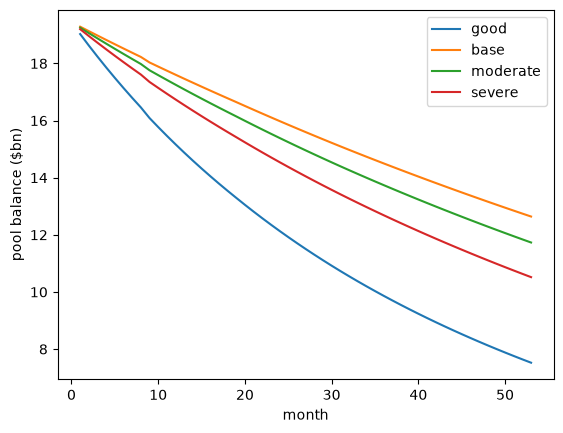

In [7]:
if results:
    for name, df in results.items():
        plt.plot(df["month"], df["ending_balance"] / 1e9, label=name)
    plt.xlabel("month"); plt.ylabel("pool balance ($bn)"); plt.legend()

**Result · Figure 3 (pool balance).** At today's rates the pool pays down **much more slowly** than under the old placeholders:

| | month 12 | month 24 | month 36 | month 53 | half paid down by |
|---|---|---|---|---|---|
| good | $15.2bn | $12.1bn | $9.9bn | **$7.52bn** | month 37 |
| base | $17.6bn | $16.0bn | $14.5bn | **$12.64bn** | not before 2031 |
| moderate | $17.3bn | $15.4bn | $13.7bn | **$11.73bn** | not before 2031 |
| severe | $16.7bn | $14.5bn | $12.7bn | **$10.52bn** | not before 2031 |

Year-1 CPR is about **21% / 8% / 10% / 13%** (good / base / moderate / severe). Only the good path, with a 1 pp rally, gets the pool into the money. In base, two-thirds of the pool is still outstanding at the Feb 2031 call.

**Q&A · Figure 3, pool balance**

**Q: Why does the base case pay down so slowly now?**
A: At 7.28% the pool's 6.76% average coupon is about 0.5 pp out of the money, so almost nobody gains from refinancing. CPR falls to the turnover level, about 8%, and scheduled principal adds only about 0.1% a month.

**Q: Why do the stress paths pay down a bit faster than base?**
A: They assume small rate cuts (to 7.03% and 6.78%), which nudge some higher-coupon loans into the money. With most loans still out of the money, the effect is small.

**Q: How does the paydown affect the notes?**
A: Slower paydown means longer note lives (higher WAL). Investors earn the spread longer, but the notes are exposed to credit losses for longer. For the first 36 months A-1 still gets its fixed paydown schedule from the senior share; the mezzanine notes amortize sequentially from the subordinate share while the triggers pass.

In [8]:
if results:
    display(pd.DataFrame({name: {
        "cum. losses ($mm)": df["losses"].sum() / 1e6,
        "cum. loss / cut-off (%)": df["losses"].sum() / cp.CUTOFF_BALANCE * 100,
        "end balance ($bn)": df["ending_balance"].iloc[-1] / 1e9,
    } for name, df in results.items()}))

,good,base,moderate,severe
cum. losses ($mm),44.0648,53.8341,66.5490,78.6437
cum. loss / cut-off (%),0.1934,0.2363,0.2921,0.3452
end balance ($bn),7.5235,12.6402,11.7314,10.5186


**Result · Losses vs the tranche stack.** Cumulative losses (good / base / moderate / severe) are **$44.1mm / $53.8mm / $66.5mm / $78.6mm**, or **0.193% / 0.236% / 0.292% / 0.345%** of the $22.78bn cut-off balance. That's higher than with the old 6.25% paths, because slower prepayment leaves more loans in the pool to default.
- The first-loss piece **B-3H covers 0–0.25%**: good and base stay inside it (base uses about 94%), while **moderate and severe go into B-2H**, by about $10mm and $22mm.
- The offered **M-2B (attaching at 1.90%), M-1 and A-1 still take no write-downs**; the severe loss is about a fifth of M-2B's attachment point.
- About $21–24mm of each scenario's loss comes from loans already delinquent on the tape, so it's locked in whatever the scenario.

> Compare cumulative loss / cut-off with the tranche bands in `docs/cashflows.md` (B-3H 0–0.25%, B-2H 0.25–1.45%, …, M-2B attaches at 1.90%). Which scenario reaches the offered notes?

**Q&A · Losses vs the tranche stack**

**Q: How do I read "loss / cut-off" against the tranches?**
A: Attachment and detachment points are percentages of the **cut-off** balance ($22.78bn). A tranche is written down only once cumulative losses pass its attachment point. B-3H covers 0–0.25%, B-2H 0.25–1.45%, B-1H 1.45–1.90%, and M-2B starts at 1.90%.

**Q: Why are the offered notes still safe in the severe case?**
A: Severe losses are 0.345% of cut-off. They use all of B-3H and about 0.095% (≈$22mm) of B-2H. The offered notes sit behind 1.90% of subordination, about 5.5× the severe loss.

**Q: Why did losses rise compared with the earlier 6.25% runs?**
A: The calibrated model already had 40–55% severity; what changed is prepayment. At 7.28% far fewer loans pay off early, so a larger balance stays in the pool through the stress and more of it defaults and liquidates before the 2031 call.

## Step 4 · Save the handoff for Smarajit

In [9]:
if results:
    out_dir = ROOT / "outputs"; out_dir.mkdir(exist_ok=True)
    for name, df in results.items():
        df.to_parquet(out_dir / f"pool_cf_{name}.parquet", index=False)
    print("saved to", out_dir)

saved to /Users/reza/Desktop/mfe-term_3/asset backed scurity market /stacr-crt-pricing/outputs


**Result · Saved.** Four files are in `outputs/`: `pool_cf_good.parquet`, `pool_cf_base.parquet`, `pool_cf_moderate.parquet` and `pool_cf_severe.parquet`, each with 53 rows and the 10 agreed columns, built from the interim paths. `python -m src.export_results` writes the same tables as CSV in `outputs/tables/`. These are what Smarajit's waterfall reads.

**Q&A · Saving the handoff**

**Q: Why parquet files, and why are they gitignored?**
A: Parquet keeps exact numeric types and loads instantly in pandas. The tables are built from licensed Bloomberg data, so they stay local (`outputs/` is gitignored) and teammates regenerate them by running this notebook.

**Q: How will Smarajit use them?**
A: Scheduled principal + prepayments make up the deal's Stated Principal, which the waterfall splits between the senior and subordinate shares. `losses` become tranche write-downs from the bottom up. `modification_losses` reduce junior interest. `distressed_balance` and cumulative losses drive the Delinquency and Cumulative Net Loss tests.

## Results and takeaways (fitted parameters, interim scenarios at today's 7.28% PMMS)

- **The table is consistent**: the balance identity holds every month, and month 1 starts at today's **$19.44bn**.
- **Prepayment is slow at today's rates**: year-1 CPR is about **21% / 8% / 10% / 13%** (good / base / moderate / severe). In base, only $138mm prepays in month 1, and the pool is still **$12.64bn** at the Feb 2031 call.
- **Pool runoff to the call**: **$7.52bn / $12.64bn / $11.73bn / $10.52bn**. The offered notes will be outstanding much longer than at the old 6.25% assumption.
- **Credit events**: $47.8mm of loans already seriously delinquent liquidate in month 9 (a $21–24mm loss). New defaults start liquidating after the fitted 19-month lag.
- **Losses**: **0.193% / 0.236% / 0.292% / 0.345%** of cut-off. Good and base stay inside **B-3H (0–0.25%)**; moderate and severe reach **B-2H**. **A-1, M-1 and M-2 take no write-downs**: M-2B needs cumulative losses above 1.90%, about 5.5× the severe case.

**What this means and what's next.** The offered notes remain well protected against credit loss, but at today's rates their main risk is **extension**: slow prepayment keeps them outstanding (and exposed) much longer. Next: (1) drop Coco's `scenarios.csv` into `data/scenarios/` and rerun; (2) add a negative-equity block on refinancing; (3) test a harsher severe path (HPI −30% or worse) to see how much stress reaches M-2B.